# 08 — Focused Qwen Classification and Machine Unlearning

# 1. Introduction

## 1.1 Purpose of This Notebook

The primary project uses a PyTorch multilayer perceptron (MLP) to predict whether acute kidney rejection is confirmed within 30 days of an assessment. This notebook extends that study to **Qwen2.5-0.5B** and asks whether the established classification and machine-unlearning framework transfers to a pretrained language model.

This is a focused extension, not a repetition of the complete five-scenario MLP study. It trains only one Qwen baseline, one Full Retraining reference, and one Gradient Difference model for a single scenario selected in advance: **Hospital Removal**.

## 1.2 Research Questions

**RQ1.** How does a Qwen classifier perform compared with the existing MLP on the kidney-transplant classification task?

**RQ2.** Can Gradient Difference approximate Full Retraining for a Qwen classifier while requiring less computation?

# Notebook Pipeline

Read and run the notebook in this order. Each selection boundary states which data it may use.

| Stage | Input | Action | Output / gate |
|---|---|---|---|
| 1. Fixed data | Existing dataset and permanent grouped splits | Select the deterministic 600-recipient subset and serialise the 18 approved features | Validated train / validation / test memberships |
| 2. Qwen classifier | Qwen2.5-0.5B + rank-8 LoRA | Train up to five epochs | Best baseline selected by validation PR-AUC |
| 3. Freeze baseline | Best baseline + validation set | Select the classification threshold | Test evaluated once after freezing |
| 4. Full Retraining | Fresh Qwen + fresh LoRA/head + retain rows only | Train the exact-unlearning reference | Best reference selected on retained validation |
| 5. Diagnose old GD | Frozen baseline + one paired retain/forget batch | Verify objective sign, loss balance and gradients | Collapse mechanism documented |
| 6. GD sensitivity | Every candidate restarts from the frozen baseline | Search 18 conservative configurations | Stability and selection use validation only |
| 7. Final GD | Selected hyperparameters + a fresh reload of the frozen baseline | Run Gradient Difference once | Final adapter saved separately |
| 8. Final evaluation | Frozen Full Retraining and final GD | Access retained test once; recompute Truth Ratio/KS and runtime | Utility, forgetting and efficiency tables |

The linked [qwen-classifier reference](https://github.com/gpjt/qwen-classifier) supports this clear separation of data, evaluation, training and checkpointing. Its Qwen3 causal-LM implementation is not copied because this study keeps Qwen2.5 sequence classification, LoRA and the existing project metrics.

# 2. Setup

## 2.1 Import Libraries

Only local project files and the locally cached Qwen checkpoint are used. There are no hosted-model or external API calls.

In [245]:
import gc
import hashlib
import json
import math
import os
import random
import time
from itertools import cycle
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from IPython.display import Markdown, display
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from scipy.stats import ks_2samp
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             f1_score, log_loss, roc_auc_score)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding)

os.environ["HF_HUB_OFFLINE"] = "1"
transformers.logging.set_verbosity_error()

## 2.2 Reproducibility

Seed 42 controls recipient sampling, model initialisation and dataloader shuffling. Apple MPS is reproducible enough for this experiment when seeds and memberships are frozen, although exact bit-for-bit equality is not guaranteed across PyTorch or macOS versions.

In [246]:
SEED = 42

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

reset_seed()

## 2.3 Hardware and Environment

MPS is preferred on Apple Silicon. A CPU fallback keeps inspection possible, but the runtime benchmark below will prevent an impractical training run.

In [247]:
MPS_AVAILABLE = torch.backends.mps.is_available()
DEVICE = torch.device("mps" if MPS_AVAILABLE else "cpu")
MODEL_DTYPE = torch.float16 if MPS_AVAILABLE else torch.float32

display(pd.Series({
    "selected_device": str(DEVICE), "MPS_available": MPS_AVAILABLE,
    "PyTorch": torch.__version__, "Transformers": transformers.__version__,
    "PEFT": peft.__version__,
}).to_frame("Value"))

,Value
selected_device,mps
MPS_available,True
PyTorch,2.12.1
Transformers,5.2.0
PEFT,0.20.0


## 2.4 Experiment Configuration

The deterministic 600-recipient subset, Qwen2.5-0.5B model and LoRA rank 8 are fixed. Baseline and Full Retraining allow at most five epochs with patience-two early stopping. Machine unlearning is enabled only after runtime, checkpoint and membership assertions pass. The accepted runtime override changes only the gate decision; it does not reduce data, epochs or model size.

In [248]:
CONFIG = {
    "qwen_model": "Qwen/Qwen2.5-0.5B",
    "qwen_subset_recipients": 600,
    "deletion_scenario": "hospital_removal", "hospital_id": "V32P-H05",
    "seed": SEED, "max_epochs": 5, "early_stopping_patience": 2, "unlearning_epochs": 1,
    "training_batch_size": 16, "evaluation_batch_size": 64,
    "learning_rate": 2e-4, "gradient_difference_learning_rate": 2e-5,
    "gradient_difference_forget_weight": 1.0,
    "gradient_difference_forget_weight": 1.0,
    "weight_decay": 0.01, "adam_epsilon": 1e-6,
    "warmup_fraction": 0.05, "gradient_clip_norm": 1.0,
    "lora_rank": 8, "lora_alpha": 16, "lora_dropout": 0.05,
    "lora_targets": ["q_proj", "v_proj"],
    "benchmark_batches": 25, "benchmark_warmup_batches": 3,
    "feasibility_threshold_minutes": 45.0,
    "allow_runtime_override": True,
    "run_class_weight_diagnostic": False,
    "run_unlearning": True,
}
display(pd.Series(CONFIG, name="Value").to_frame())

,Value
qwen_model,Qwen/Qwen2.5-0.5B
qwen_subset_recipients,600
deletion_scenario,hospital_removal
hospital_id,V32P-H05
seed,42
max_epochs,5
early_stopping_patience,2
unlearning_epochs,1
training_batch_size,16
evaluation_batch_size,64


# 3. Prepare the LLM Dataset

## 3.1 Load the Existing Kidney Dataset

The immutable project dataset and feature contract are reused. **No new synthetic records are generated in this notebook.**

In [249]:
def locate_submission_root():
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data/final/kidney_transplant_assessments.csv").is_file():
            return candidate
        nested = candidate / "code/final_submission"
        if (nested / "data/final/kidney_transplant_assessments.csv").is_file():
            return nested
    raise FileNotFoundError("Could not locate code/final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
AUDIT_PATH = ROOT / "data/final/deletion_scenario_audit.csv"
MODEL_ROOT = ROOT / "models/qwen_classifier_focused"
RESULT_ROOT = ROOT / "results/qwen_classifier_focused"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

In [250]:
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
FEATURES = feature_contract["classifier_features"]
TARGET = feature_contract["target"]

assert len(assessments) == 60_000
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()
assert len(FEATURES) == 18 and TARGET in assessments

display(pd.Series({
    "assessments": len(assessments), "recipients": assessments["recipient_id"].nunique(),
    "target": TARGET, "positive_count": int(assessments[TARGET].sum()),
    "negative_count": int((1 - assessments[TARGET]).sum()),
    "positive_rate": assessments[TARGET].mean(),
}).to_frame("Value"))

,Value
assessments,60000
recipients,10000
target,acute_rejection_within_30_days
positive_count,4494
negative_count,55506
positive_rate,0.0749


## 3.2 Load the Existing Permanent Split

The permanent split is donor-grouped, which is stricter than recipient grouping: assessments for the same recipient—and recipients linked to the same donor—cannot cross partitions. This prevents longitudinal leakage.

In [251]:
split_assignments = pd.read_csv(SPLIT_PATH)
assert split_assignments["recipient_id"].is_unique
assert set(split_assignments["split"]) == {"train", "validation", "test"}

working = assessments.merge(
    split_assignments[["recipient_id", "donor_id", "recipient_target_any", "split"]],
    on=["recipient_id", "donor_id"], how="left", validate="many_to_one",
)
assert working["split"].notna().all()
assert working.groupby("recipient_id")["split"].nunique().eq(1).all()
assert working.groupby("recipient_id").size().eq(6).all()

recipient_sets = {name: set(working.loc[working["split"].eq(name), "recipient_id"])
                  for name in ["train", "validation", "test"]}
assert recipient_sets["train"].isdisjoint(recipient_sets["validation"])
assert recipient_sets["train"].isdisjoint(recipient_sets["test"])
assert recipient_sets["validation"].isdisjoint(recipient_sets["test"])
display(working.groupby("split").size().reindex(["train", "validation", "test"]).to_frame("Assessments"))

,Assessments
split,
train,42024
validation,8988
test,8988


## 3.3 Create the Qwen Experimental Subset

The Qwen extension uses a fixed recipient-level subset for computational feasibility while preserving the longitudinal structure of the dataset. Sampling is stratified by permanent split and recipient-level target status; individual assessments are never sampled.

In [252]:
def proportional_allocation(group_sizes, total):
    exact = group_sizes / group_sizes.sum() * total
    allocation = np.floor(exact).astype(int)
    remainder = total - allocation.sum()
    for name in (exact - allocation).sort_values(ascending=False).index[:remainder]:
        allocation[name] += 1
    return allocation

recipient_table = split_assignments.copy()
split_sizes = recipient_table["split"].value_counts().reindex(["train", "validation", "test"])
allocation = proportional_allocation(split_sizes, CONFIG["qwen_subset_recipients"])
display(allocation.to_frame("Sampled recipients"))

,Sampled recipients
split,
train,420
validation,90
test,90


In [253]:
# Sample complete recipient histories; never sample individual assessments.
sampled_recipients = []
for split_name in ["train", "validation", "test"]:
    candidates = recipient_table.loc[recipient_table["split"].eq(split_name)]
    selected, _ = train_test_split(
        candidates, train_size=int(allocation[split_name]),
        stratify=candidates["recipient_target_any"], random_state=SEED,
    )
    sampled_recipients.extend(selected["recipient_id"].tolist())

subset = working.loc[working["recipient_id"].isin(sampled_recipients)].copy()
subset = subset.sort_values("assessment_id").reset_index(drop=True)
assert subset["recipient_id"].nunique() == CONFIG["qwen_subset_recipients"]
assert len(subset) == CONFIG["qwen_subset_recipients"] * 6
assert subset.groupby("recipient_id").size().eq(6).all()
assert subset.groupby("recipient_id")["split"].nunique().eq(1).all()

## 3.4 Check Subset Representativeness

Simple prevalence and split checks can identify obvious distortion, but they do not prove statistical representativeness.

**Why this matters.** The subset keeps every recipient's six-assessment history intact and preserves original partition membership. The displayed prevalence differences describe how closely this deterministic sample resembles the full dataset; they are not a claim of formal representativeness.

In [254]:
representativeness = subset.groupby("split").agg(
    assessments=("assessment_id", "size"), recipients=("recipient_id", "nunique"),
    positive_rate=(TARGET, "mean"),
).reindex(["train", "validation", "test"])
representativeness["full_split_positive_rate"] = working.groupby("split")[TARGET].mean()
representativeness["absolute_rate_difference"] = (
    representativeness["positive_rate"] - representativeness["full_split_positive_rate"]
).abs()
display(representativeness.style.format(precision=4))

,assessments,recipients,positive_rate,full_split_positive_rate,absolute_rate_difference
split,,,,,
train,2520,420,0.0813,0.0752,0.0062
validation,540,90,0.0815,0.0744,0.0070
test,540,90,0.0759,0.0740,0.0019


## 3.5 Class Distribution by Split

Positive examples must be present in every partition for training, validation and final testing to be meaningful. The table keeps recipient and assessment counts visible alongside the full-dataset positive rate.

**Why this matters.** Every split contains positive acute-rejection examples, so PR-AUC, AUROC and validation-based checkpoint selection can be calculated. The validation and test positive counts remain modest, so small metric differences should be interpreted cautiously; these checks do not by themselves prove representativeness.

In [255]:
class_distribution = subset.groupby("split").agg(
    Recipients=("recipient_id", "nunique"),
    Assessments=("assessment_id", "size"),
    Positive_Cases=(TARGET, "sum"),
    Positive_Rate=(TARGET, "mean"),
).reindex(["train", "validation", "test"])
class_distribution["Full_Dataset_Positive_Rate"] = assessments[TARGET].mean()
class_distribution.index.name = "Split"
display(class_distribution.style.format({
    "Positive_Rate": "{:.4f}", "Full_Dataset_Positive_Rate": "{:.4f}"
}))

,Recipients,Assessments,Positive_Cases,Positive_Rate,Full_Dataset_Positive_Rate
Split,,,,,
train,420,2520,205,0.0813,0.0749
validation,90,540,44,0.0815,0.0749
test,90,540,41,0.0759,0.0749


In [256]:
selected_split_counts = subset.groupby("recipient_id")["split"].nunique()
selected_history_counts = subset.groupby("recipient_id").size()
assert selected_split_counts.eq(1).all()
assert selected_history_counts.eq(6).all()
assert class_distribution["Positive_Cases"].gt(0).all()

subset_checks = pd.DataFrame({
    "Check": ["No recipient crosses splits", "All six assessments retained",
              "Positive cases in every split"],
    "Status": ["PASS", "PASS", "PASS"],
})
display(subset_checks)

,Check,Status
0,No recipient crosses splits,PASS
1,All six assessments retained,PASS
2,Positive cases in every split,PASS


# 4. Convert Tabular Records into Qwen Input

## 4.1 Define Classifier Features

An LLM can classify tabular data after each row is serialised into consistent text. The same 18 approved MLP features are included. IDs, direct identifiers, the target, dates and consent/audit fields are **not used by the classifier**.

In [257]:
NOT_USED = {
    "assessment_id", "recipient_id", "donor_id", "hospital_id", TARGET,
    "assessment_date", "training_consent_status", "training_consent_version",
    "retention_expiry_date", "split", "recipient_target_any",
}
assert NOT_USED.isdisjoint(FEATURES)
display(pd.DataFrame({"USED BY CLASSIFIER": pd.Series(FEATURES),
                      "NOT USED BY CLASSIFIER": pd.Series(sorted(NOT_USED))}))

,USED BY CLASSIFIER,NOT USED BY CLASSIFIER
0,recipient_age,acute_rejection_within_30_days
1,donor_age,assessment_date
2,donor_type,assessment_id
3,kidney_failure_cause,donor_id
4,previous_transplant,hospital_id
5,dialysis_months,recipient_id
6,abo_compatibility_category,recipient_target_any
7,hla_mismatch_count,retention_expiry_date
8,antibody_risk_score,split
9,cold_ischaemia_hours,training_consent_status


## 4.2 Convert Each Assessment to Compact Structured Text

Short, documented aliases reduce token count without removing features. Values are rendered deterministically; no natural-language prompt or generated answer is used.

In [258]:
ALIASES = {
    "recipient_age": "r_age", "donor_age": "d_age", "donor_type": "donor_type",
    "kidney_failure_cause": "kidney_cause", "previous_transplant": "prev_tx",
    "dialysis_months": "dialysis_mo", "abo_compatibility_category": "abo",
    "hla_mismatch_count": "hla", "antibody_risk_score": "antibody",
    "cold_ischaemia_hours": "cold_isch_h", "days_since_transplant": "post_tx_d",
    "creatinine_mg_dl": "creatinine", "creatinine_change_pct": "creatinine_delta",
    "urine_output_ml_24h": "urine_24h", "tacrolimus_level_ng_ml": "tacrolimus",
    "medication_adherence_pct": "adherence", "infection_indicator": "infection",
    "previous_rejection": "prev_rejection",
}
assert list(ALIASES) == FEATURES

def compact_value(value):
    if pd.isna(value): return "missing"
    if isinstance(value, (float, np.floating)): return f"{value:.4g}"
    return str(value)

def assessment_to_text(row):
    return " | ".join(f"{ALIASES[name]}={compact_value(row[name])}" for name in FEATURES)

subset["qwen_text"] = subset.apply(assessment_to_text, axis=1)

## 4.3 Show One Example Assessment

The table shows the source values; the line below it is exactly what Qwen receives.

In [259]:
example = subset.loc[subset["split"].eq("train")].iloc[0]
display(example[FEATURES].rename("Original value").to_frame())
display(Markdown(f"**Structured Qwen text**  \n`{example['qwen_text']}`"))

,Original value
recipient_age,57
donor_age,67
donor_type,Living
kidney_failure_cause,Other
previous_transplant,0
dialysis_months,52
abo_compatibility_category,Standard compatible
hla_mismatch_count,3
antibody_risk_score,0.263
cold_ischaemia_hours,18.51


**Structured Qwen text**  
`r_age=57 | d_age=67 | donor_type=Living | kidney_cause=Other | prev_tx=0 | dialysis_mo=52 | abo=Standard compatible | hla=3 | antibody=0.263 | cold_isch_h=18.51 | post_tx_d=7 | creatinine=1.74 | creatinine_delta=0.7528 | urine_24h=2350 | tacrolimus=12 | adherence=98.8 | infection=0 | prev_rejection=0`

## 4.4 Tokenise the Text

The tokenizer converts structured text into numerical token IDs. Dynamic padding pads only to the longest sequence in each batch, while truncation provides a safety boundary.

In [260]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["qwen_model"], local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
raw_tokens = tokenizer(subset["qwen_text"].tolist(), add_special_tokens=True, truncation=False)
token_lengths = np.array([len(ids) for ids in raw_tokens["input_ids"]])

## 4.5 Analyse Sequence Lengths

`MAX_LENGTH` is selected only after observing the compact representation. It is rounded to a multiple of eight and capped at 256; truncation remains enabled as a safeguard.

**Why this matters.** The compact `name=value` representation avoids prompt boilerplate and repeated phrases. Its measured lengths determine the safety limit above; shorter sequences reduce computation in every Qwen layer.

In [261]:
length_summary = pd.Series({
    "mean": token_lengths.mean(), "median": np.median(token_lengths),
    "95th_percentile": np.percentile(token_lengths, 95), "maximum": token_lengths.max(),
})
MAX_LENGTH = int(min(256, max(32, math.ceil(token_lengths.max() / 8) * 8)))
CONFIG["maximum_length"] = MAX_LENGTH
length_summary["chosen_MAX_LENGTH"] = MAX_LENGTH
length_summary["rows_exceeding_MAX_LENGTH"] = int((token_lengths > MAX_LENGTH).sum())
display(length_summary.to_frame("Tokens"))

,Tokens
mean,129.165833
median,129.000000
95th_percentile,133.000000
maximum,137.000000
chosen_MAX_LENGTH,144.000000
rows_exceeding_MAX_LENGTH,0.000000


# 5. Build the Qwen Classifier

## 5.1 Load Qwen2.5-0.5B

Qwen is already pretrained. This notebook does not train a language model from scratch. `AutoModelForSequenceClassification` attaches a binary sequence-classification head to the cached checkpoint.

In [262]:
LORA_CONFIG = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=CONFIG["lora_rank"],
    lora_alpha=CONFIG["lora_alpha"], lora_dropout=CONFIG["lora_dropout"],
    target_modules=CONFIG["lora_targets"], modules_to_save=["score"], bias="none",
)

def load_qwen_base():
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["qwen_model"], num_labels=2, dtype=MODEL_DTYPE, local_files_only=True,
        id2label={0: "no_rejection", 1: "acute_rejection"},
        label2id={"no_rejection": 0, "acute_rejection": 1},
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    return model

## 5.3 What is LoRA and Why Is It Used?

**LoRA means Low-Rank Adaptation.** Qwen contains hundreds of millions of pretrained parameters, so updating every weight would require substantial compute and optimiser memory. LoRA freezes those original weights and inserts small trainable low-rank matrices into selected layers; the classification head is also trainable.

Full-parameter Qwen fine-tuning was computationally impractical on the available hardware. LoRA allows the kidney-transplant classification task to adapt Qwen using a much smaller set of trainable parameters.

The machine-unlearning experiment therefore targets the influence of the kidney-transplant records on the task-specific LoRA adaptation and classification head. **It does not attempt to remove information from Qwen's original pretrained base model.**

## 5.4 Add LoRA to Qwen

Rank 8 adapters are inserted into attention query and value projections (`q_proj` and `v_proj`), matching the established project implementation.

In [263]:
reset_seed()
inspection_model = get_peft_model(load_qwen_base(), LORA_CONFIG).to(DEVICE)
inspection_model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

## 5.5 Verify Trainable Parameters

The audit is calculated from the actual model. Assertions ensure only LoRA matrices and the saved classification head can receive gradients.

**Why this matters.** The trainable percentage quantifies how much of the adapted classifier needs gradients and optimiser state. The frozen base still participates in every pass, so LoRA reduces memory and update cost but does not make Qwen as cheap as the MLP.

In [264]:
total_parameters = sum(p.numel() for p in inspection_model.parameters())
trainable_parameters = sum(p.numel() for p in inspection_model.parameters() if p.requires_grad)
trainable_names = [name for name, p in inspection_model.named_parameters() if p.requires_grad]

assert trainable_names
assert all("lora_" in name or "modules_to_save" in name for name in trainable_names)
assert all(not p.requires_grad for name, p in inspection_model.named_parameters()
           if "lora_" not in name and "modules_to_save" not in name)

display(pd.DataFrame({
    "Measure": ["Total parameters", "Trainable parameters", "Trainable percentage"],
    "Value": [total_parameters, trainable_parameters,
              100 * trainable_parameters / total_parameters],
}))

,Measure,Value
0,Total parameters,4.945770e+08
1,Trainable parameters,5.424640e+05
2,Trainable percentage,1.096824e-01


# 6. Runtime Feasibility Check

The previous implementation ran for approximately **651 minutes** before interruption. This section benchmarks real subset batches before any baseline or unlearning experiment is allowed to start.

## 6.1 Prepare a Benchmark Loader

In [265]:
# Tokenise once; loaders below reference immutable row positions.
encoded = tokenizer(
    subset["qwen_text"].tolist(), truncation=True,
    max_length=MAX_LENGTH, padding=False,
)
LABELS = subset[TARGET].astype(int).to_numpy()

class TokenDataset(Dataset):
    def __init__(self, positions):
        self.positions = np.asarray(positions, dtype=np.int64)
    def __len__(self):
        return len(self.positions)
    def __getitem__(self, item):
        position = int(self.positions[item])
        return {"input_ids": encoded["input_ids"][position],
                "attention_mask": encoded["attention_mask"][position],
                "labels": int(LABELS[position]), "row_index": position}

collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)
split_positions = {name: subset.index[subset["split"].eq(name)].to_numpy()
                   for name in ["train", "validation", "test"]}

In [266]:
def make_loader(positions, batch_size, shuffle=False, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(TokenDataset(positions), batch_size=batch_size, shuffle=shuffle,
                      generator=generator, num_workers=0, collate_fn=collator)

def class_weights(positions):
    y = LABELS[np.asarray(positions)]
    positive = int(y.sum()); negative = len(y) - positive
    assert positive and negative
    return torch.tensor([1.0, negative / positive], dtype=torch.float32, device=DEVICE)

def linear_warmup_decay(step, total_steps):
    warmup_steps = max(1, int(total_steps * CONFIG["warmup_fraction"]))
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

benchmark_loader = make_loader(
    split_positions["train"], CONFIG["training_batch_size"], shuffle=True
)
display(pd.Series({"real_training_rows": len(split_positions["train"]),
                   "benchmark_batches": CONFIG["benchmark_batches"],
                   "batch_size": CONFIG["training_batch_size"]}).to_frame("Value"))

,Value
real_training_rows,2520
benchmark_batches,25
batch_size,16


## 6.2 Run a Short Training Benchmark

Three untimed batches absorb initial MPS graph compilation and allocation. The following 25 batches measure the same forward, backward, clipping and optimiser work used by baseline training.

In [267]:
def benchmark_training(model, loader):
    model.train()
    optimiser = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),
                                  lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"],
                                  eps=CONFIG["adam_epsilon"])
    weights = class_weights(split_positions["train"])
    iterator = cycle(loader); durations = []
    total = CONFIG["benchmark_warmup_batches"] + CONFIG["benchmark_batches"]
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimiser, lambda step: linear_warmup_decay(step, total))
    for step in tqdm(range(total), desc="Runtime benchmark"):
        batch = next(iterator); batch.pop("row_index")
        labels = batch.pop("labels").to(DEVICE)
        inputs = {name: value.to(DEVICE) for name, value in batch.items()}
        if DEVICE.type == "mps": torch.mps.synchronize()
        started = time.perf_counter(); optimiser.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(**inputs).logits.float(), labels, weight=weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad),
                                      CONFIG["gradient_clip_norm"])
        optimiser.step(); scheduler.step()
        if DEVICE.type == "mps": torch.mps.synchronize()
        if step >= CONFIG["benchmark_warmup_batches"]:
            durations.append(time.perf_counter() - started)
    return durations

benchmark_durations = benchmark_training(inspection_model, benchmark_loader)
seconds_per_batch = float(np.mean(benchmark_durations))
display(pd.Series({"elapsed_seconds": sum(benchmark_durations),
                   "measured_batches": len(benchmark_durations),
                   "seconds_per_batch": seconds_per_batch}).to_frame("Value"))

Runtime benchmark:   0%|          | 0/28 [00:00<?, ?it/s]

,Value
elapsed_seconds,21.551752
measured_batches,25.000000
seconds_per_batch,0.862070


## 6.3 Estimate Complete Experiment Runtime

The estimate includes up to five baseline epochs, validation after every epoch, up to five fresh Full Retraining epochs, Gradient Difference, and required evaluations. The experiment must stop before expensive work if the estimated total exceeds 45 minutes.

In [268]:
hospital_mask = subset["hospital_id"].eq(CONFIG["hospital_id"])
forget_positions = subset.index[subset["split"].eq("train") & hospital_mask].to_numpy()
retain_positions = subset.index[subset["split"].eq("train") & ~hospital_mask].to_numpy()
retained_validation_positions = subset.index[
    subset["split"].eq("validation") & ~hospital_mask].to_numpy()
retained_test_positions = subset.index[
    subset["split"].eq("test") & ~hospital_mask].to_numpy()

def batches(rows):
    return math.ceil(rows / CONFIG["training_batch_size"])

validation_cost = lambda rows: 0.5 * batches(rows)
baseline_seconds = seconds_per_batch * CONFIG["max_epochs"] * (
    batches(len(split_positions["train"])) + validation_cost(len(split_positions["validation"])))
full_seconds = seconds_per_batch * CONFIG["max_epochs"] * (
    batches(len(retain_positions)) + validation_cost(len(retained_validation_positions)))
# Each GD update evaluates one retain and one forget batch.
gd_pass_seconds = seconds_per_batch * 2 * batches(len(forget_positions))
# The fixed grid contains nine one-pass and nine two-pass candidates.
gd_search_seconds = gd_pass_seconds * (9 * 1 + 9 * 2)
final_gd_seconds = gd_pass_seconds * 2
evaluation_seconds = seconds_per_batch * 0.5 * (
    batches(len(split_positions["test"])) + 2 * batches(len(retained_test_positions))
    + 2 * batches(len(forget_positions)))
benchmark_seconds = seconds_per_batch * (
    CONFIG["benchmark_batches"] + CONFIG["benchmark_warmup_batches"])

In [269]:
runtime_estimate = pd.DataFrame({
    "Stage": ["Baseline (up to 5 epochs)", "Full Retraining (up to 5 epochs)",
              "GD validation search (18 candidates)", "Final GD (up to 2 passes)",
              "Required evaluation", "TOTAL including benchmark"],
    "Estimated Runtime (minutes)": [baseline_seconds / 60, full_seconds / 60,
        gd_search_seconds / 60, final_gd_seconds / 60, evaluation_seconds / 60,
        (benchmark_seconds + baseline_seconds + full_seconds + gd_search_seconds
         + final_gd_seconds + evaluation_seconds) / 60],
})
estimated_total_minutes = float(runtime_estimate.iloc[-1, 1])
FINAL_EXPERIMENT_FEASIBLE = estimated_total_minutes <= CONFIG["feasibility_threshold_minutes"]
RUNTIME_ACCEPTED = FINAL_EXPERIMENT_FEASIBLE or CONFIG["allow_runtime_override"]
RUN_BASELINE = RUNTIME_ACCEPTED
RUN_UNLEARNING = bool(CONFIG["run_unlearning"] and RUNTIME_ACCEPTED)
runtime_estimate.to_csv(RESULT_ROOT / "runtime_estimate.csv", index=False)
display(runtime_estimate.style.format({"Estimated Runtime (minutes)": "{:.1f}"}))

,Stage,Estimated Runtime (minutes)
0,Baseline (up to 5 epochs),12.6
1,Full Retraining (up to 5 epochs),11.4
2,GD validation search (18 candidates),11.6
3,Final GD (up to 2 passes),0.9
4,Required evaluation,0.9
5,TOTAL including benchmark,37.8


### Runtime Decision

This gate is evaluated before baseline, Full Retraining, or Gradient Difference begins. No dataset, epoch, rank, or algorithm setting is silently reduced.

In [270]:
# Stop before unlearning unless runtime, baseline and data-membership gates all passed.
if not RUNTIME_ACCEPTED:
    raise RuntimeError(
        f"STOP: estimated complete runtime {estimated_total_minutes:.1f} minutes exceeds 45 minutes.")
runtime_note = "explicitly accepted override" if not FINAL_EXPERIMENT_FEASIBLE else "within safety threshold"
display(Markdown(
    f"✅ **Complete experiment may proceed:** estimated total runtime is "
    f"**{estimated_total_minutes:.1f} minutes** ({runtime_note})."))

def require_baseline_feasible():
    if not RUN_BASELINE:
        raise RuntimeError("Runtime gate blocked baseline training.")

def require_unlearning_enabled():
    if not RUN_UNLEARNING:
        raise RuntimeError("Machine-unlearning execution gate is disabled.")

del inspection_model
gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()

✅ **Complete experiment may proceed:** estimated total runtime is **37.8 minutes** (within safety threshold).

# 7. Train and Evaluate the Qwen Baseline

## 7.1 Extend the Baseline to a Maximum of Five Epochs

The previous three-epoch experiment showed that validation PR-AUC was still improving at epoch 3. The maximum was therefore extended to five epochs to determine whether the model had reached convergence. The final model is still selected using validation performance rather than simply taking the last epoch.

Validation PR-AUC is checked after every epoch. Training stops after two consecutive epochs without improvement, and test data are never used for checkpoint selection.

In [271]:
training_configuration = pd.Series({
    "maximum_epochs": CONFIG["max_epochs"],
    "early_stopping_patience": CONFIG["early_stopping_patience"],
    "batch_size": CONFIG["training_batch_size"],
    "learning_rate": CONFIG["learning_rate"],
    "LoRA_rank": CONFIG["lora_rank"],
    "checkpoint_metric": "validation PR-AUC",
    "threshold_policy": "maximum validation F1; no test tuning",
    "unlearning_enabled": RUN_UNLEARNING,
})
display(training_configuration.to_frame("Value"))

,Value
maximum_epochs,5
early_stopping_patience,2
batch_size,16
learning_rate,0.0002
LoRA_rank,8
checkpoint_metric,validation PR-AUC
threshold_policy,maximum validation F1; no test tuning
unlearning_enabled,True


## 7.2 Class-Imbalance Strategy

The established inverse-frequency class weighting remains fixed. It is applied consistently to the final baseline and fresh Full Retraining reference.

In [272]:
def class_weight_value(positions, strategy="inverse_frequency"):
    y = LABELS[np.asarray(positions)]
    positive = int(y.sum()); negative = len(y) - positive
    values = {"inverse_frequency": negative / positive,
              "sqrt_inverse_frequency": math.sqrt(negative / positive),
              "no_weighting": 1.0}
    if strategy not in values: raise ValueError(f"Unknown strategy: {strategy}")
    return positive, negative, values[strategy]

def class_weights(positions, strategy="inverse_frequency"):
    _, _, positive_weight = class_weight_value(positions, strategy)
    return torch.tensor([1.0, positive_weight], dtype=torch.float32, device=DEVICE)

selected_weight_strategy = "inverse_frequency"
train_positive, train_negative, positive_weight = class_weight_value(
    split_positions["train"], selected_weight_strategy)
display(pd.Series({"negative_rows": train_negative, "positive_rows": train_positive,
    "positive_class_weight": positive_weight,
    "selected_strategy": selected_weight_strategy}).to_frame("Value"))

,Value
negative_rows,2315
positive_rows,205
positive_class_weight,11.292683
selected_strategy,inverse_frequency


## 7.3 Training and Evaluation Helpers

Only LoRA and classification-head parameters are trainable. The generic routine below is used for both baseline training and fresh Full Retraining, while keeping their data memberships and checkpoint directories separate.

In [273]:
def load_classifier(adapter_path=None, trainable=True, seed=SEED):
    reset_seed(seed)
    base = load_qwen_base()
    model = (get_peft_model(base, LORA_CONFIG) if adapter_path is None else
             PeftModel.from_pretrained(base, adapter_path, is_trainable=trainable,
                                       local_files_only=True))
    model.config.pad_token_id = tokenizer.pad_token_id
    names = [name for name, parameter in model.named_parameters() if parameter.requires_grad]
    if trainable:
        assert names and all("lora_" in name or "modules_to_save" in name for name in names)
        assert all(not parameter.requires_grad for name, parameter in model.named_parameters()
                   if "lora_" not in name and "modules_to_save" not in name)
    return model.to(DEVICE)

def membership_hash(positions):
    ids = subset.loc[np.asarray(positions), "assessment_id"].astype(str)
    return hashlib.sha256("\n".join(ids).encode()).hexdigest()

In [274]:
@torch.no_grad()
def predict_probabilities(model, positions, description="Inference"):
    model.eval(); probabilities = []; returned = []
    loader = make_loader(positions, CONFIG["evaluation_batch_size"], shuffle=False)
    for batch in tqdm(loader, desc=description, leave=False):
        returned.append(batch.pop("row_index").numpy())
        batch.pop("labels")
        inputs = {name: value.to(DEVICE) for name, value in batch.items()}
        probabilities.append(torch.softmax(model(**inputs).logits.float(), dim=1)[:, 1].cpu().numpy())
    assert np.array_equal(np.concatenate(returned), np.asarray(positions))
    return np.concatenate(probabilities).astype(np.float64)

def select_threshold(y_true, probabilities):
    rows = []
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        predictions = (probabilities >= threshold).astype(int)
        rows.append({"threshold": threshold,
            "f1": f1_score(y_true, predictions, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, predictions)})
    table = pd.DataFrame(rows)
    chosen = table.sort_values(["f1", "balanced_accuracy", "threshold"],
        ascending=[False, False, True], kind="mergesort").iloc[0]
    return float(chosen["threshold"]), table

In [275]:
def binary_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    bce = log_loss(y_true, probabilities, labels=[0, 1])
    metrics = {"n": len(y_true), "positive_count": int(np.sum(y_true)),
        "threshold": threshold, "pr_auc": average_precision_score(y_true, probabilities),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "binary_cross_entropy": bce,
        "f1": f1_score(y_true, predictions, zero_division=0),
        "auroc": roc_auc_score(y_true, probabilities), "bce_quality": np.exp(-bce)}
    names = ["pr_auc", "balanced_accuracy", "f1", "auroc", "bce_quality"]
    components = np.maximum([metrics[name] for name in names], 1e-12)
    metrics["composite_utility"] = float(len(components) / np.sum(1 / components))
    return metrics

def completion_matches(model_dir, signature):
    path = model_dir / "completion.json"
    if not path.is_file(): return False
    saved = json.loads(path.read_text())
    return saved.get("status") == "completed" and saved.get("signature") == signature

In [276]:
def make_optimizer_scheduler(model, learning_rate, total_steps):
    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),
        lr=learning_rate, weight_decay=CONFIG["weight_decay"], eps=CONFIG["adam_epsilon"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda step: linear_warmup_decay(step, total_steps))
    return optimizer, scheduler

def train_epoch(model, loader, weights, optimizer, scheduler, epoch, description):
    model.train(); total_loss = 0.0; seen = 0
    if DEVICE.type == "mps": torch.mps.synchronize()
    started = time.perf_counter()
    progress = tqdm(loader, desc=f"{description} epoch {epoch}")
    for batch in progress:
        batch.pop("row_index"); labels = batch.pop("labels").to(DEVICE)
        inputs = {name: value.to(DEVICE) for name, value in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(**inputs).logits.float(), labels, weight=weights)
        if not torch.isfinite(loss): raise FloatingPointError("Non-finite training loss")
        loss.backward(); torch.nn.utils.clip_grad_norm_(
            (p for p in model.parameters() if p.requires_grad), CONFIG["gradient_clip_norm"])
        optimizer.step(); scheduler.step()
        seen += len(labels); total_loss += float(loss.detach().cpu()) * len(labels)
        progress.set_postfix(loss=f"{total_loss / seen:.4f}")
    if DEVICE.type == "mps": torch.mps.synchronize()
    return total_loss / seen, time.perf_counter() - started

In [277]:
def validation_record(model, positions, epoch, train_loss, elapsed_seconds, description):
    probabilities = predict_probabilities(model, positions, f"{description} validation {epoch}")
    threshold, _ = select_threshold(LABELS[positions], probabilities)
    metrics = binary_metrics(LABELS[positions], probabilities, threshold)
    row = {"epoch": epoch, "train_loss": train_loss,
        "validation_pr_auc": metrics["pr_auc"], "validation_auroc": metrics["auroc"],
        "validation_balanced_accuracy": metrics["balanced_accuracy"],
        "validation_f1": metrics["f1"],
        "validation_bce": metrics["binary_cross_entropy"],
        "elapsed_seconds": elapsed_seconds}
    return row, metrics

def training_signature(tag, train_positions, validation_positions, learning_rate, initialisation):
    return {"tag": tag, "initialisation": initialisation, "model": CONFIG["qwen_model"],
        "seed": SEED, "max_epochs": CONFIG["max_epochs"],
        "early_stopping_patience": CONFIG["early_stopping_patience"],
        "batch_size": CONFIG["training_batch_size"], "learning_rate": learning_rate,
        "maximum_length": MAX_LENGTH, "adam_epsilon": CONFIG["adam_epsilon"],
        "warmup_fraction": CONFIG["warmup_fraction"], "lora_rank": CONFIG["lora_rank"],
        "lora_alpha": CONFIG["lora_alpha"], "lora_targets": CONFIG["lora_targets"],
        "class_weight_strategy": selected_weight_strategy,
        "training_membership_sha256": membership_hash(train_positions),
        "validation_membership_sha256": membership_hash(validation_positions)}

In [278]:
def save_selected_checkpoint(model, model_dir, epoch, metrics, tag):
    model_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(model_dir, safe_serialization=True)
    tokenizer.save_pretrained(model_dir)
    metadata = {"tag": tag, "epoch": epoch,
        "validation_pr_auc": metrics["pr_auc"], "validation_auroc": metrics["auroc"],
        "validation_bce": metrics["binary_cross_entropy"],
        "validation_balanced_accuracy": metrics["balanced_accuracy"],
        "validation_f1": metrics["f1"], "class_weight_strategy": selected_weight_strategy,
        "selection_rule": "maximum validation PR-AUC; earliest epoch breaks exact ties",
        "configuration": CONFIG, "seed": SEED}
    (model_dir / "best_checkpoint_metadata.json").write_text(json.dumps(metadata, indent=2))
    return metadata

def finish_selected_training(model, model_dir, history, metadata, signature, training_seconds, stopped):
    history.to_csv(model_dir / "training_history.csv", index=False)
    completion = {"status": "completed", "signature": signature,
        "best_epoch": metadata["epoch"], "best_validation_pr_auc": metadata["validation_pr_auc"],
        "epochs_completed": int(len(history)), "early_stopping_triggered": bool(stopped),
        "training_seconds": training_seconds, "qwen_base_frozen": True}
    (model_dir / "completion.json").write_text(json.dumps(completion, indent=2))
    del model; gc.collect()
    if DEVICE.type == "mps": torch.mps.empty_cache()
    return load_classifier(model_dir, trainable=False), history, metadata, completion

In [279]:
# Fresh runs start from pretrained Qwen; exact-signature caches only reload completed checkpoints.
def fit_validation_selected(tag, train_positions, validation_positions,
                            model_dir, learning_rate, initialisation):
    require_baseline_feasible()
    signature = training_signature(tag, train_positions, validation_positions,
                                   learning_rate, initialisation)
    history_path = model_dir / "training_history.csv"
    metadata_path = model_dir / "best_checkpoint_metadata.json"
    if completion_matches(model_dir, signature) and history_path.is_file():
        return (load_classifier(model_dir, trainable=False), pd.read_csv(history_path),
                json.loads(metadata_path.read_text()),
                json.loads((model_dir / "completion.json").read_text()))
    model = load_classifier(trainable=True)
    loader = make_loader(train_positions, CONFIG["training_batch_size"], shuffle=True)
    weights = class_weights(train_positions, selected_weight_strategy)
    optimizer, scheduler = make_optimizer_scheduler(
        model, learning_rate, len(loader) * CONFIG["max_epochs"])
    rows = []; best_pr = -np.inf; metadata = None; no_improvement = 0
    total_training_seconds = 0.0; stopped = False
    for epoch in range(1, CONFIG["max_epochs"] + 1):
        loss, seconds = train_epoch(model, loader, weights, optimizer, scheduler, epoch, tag)
        total_training_seconds += seconds
        row, metrics = validation_record(model, validation_positions, epoch, loss,
                                         total_training_seconds, tag)
        improved = metrics["pr_auc"] > best_pr
        row["best_so_far"] = improved; rows.append(row)
        if improved:
            best_pr = metrics["pr_auc"]; no_improvement = 0
            metadata = save_selected_checkpoint(model, model_dir, epoch, metrics, tag)
        else:
            no_improvement += 1
        if no_improvement >= CONFIG["early_stopping_patience"]:
            stopped = True; break
    history = pd.DataFrame(rows)
    return finish_selected_training(model, model_dir, history, metadata, signature,
                                    total_training_seconds, stopped)

## 7.4 Train the Revised Maximum-Five-Epoch Baseline

The run starts from fresh pretrained Qwen with fresh LoRA and classification-head parameters. The best adapter is saved whenever validation PR-AUC improves.

In [280]:
PREVIOUS_THREE_EPOCH_METRICS = {
    "pr_auc": 0.10902738011451138, "balanced_accuracy": 0.5386138129918373,
    "binary_cross_entropy": 0.34892530113406983, "f1": 0.1487603305785124,
    "auroc": 0.6475634195219708, "composite_utility": 0.2413984703680979}
baseline_dir = MODEL_ROOT / "baseline_best_max5"
baseline_model, baseline_history, baseline_metadata, baseline_completion = fit_validation_selected(
    "Qwen baseline", split_positions["train"], split_positions["validation"],
    baseline_dir, CONFIG["learning_rate"], "fresh pretrained Qwen + fresh LoRA/head")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

## 7.5 Training History

Validation is performed after every completed epoch. `Best So Far` marks checkpoints that improved validation PR-AUC.

In [281]:
history_display = baseline_history.rename(columns={
    "epoch": "Epoch", "train_loss": "Train Loss", "validation_pr_auc": "Validation PR-AUC",
    "validation_auroc": "Validation AUROC",
    "validation_balanced_accuracy": "Validation Balanced Accuracy",
    "validation_f1": "Validation F1", "validation_bce": "Validation BCE",
    "elapsed_seconds": "Elapsed Time", "best_so_far": "Best So Far"})
display(history_display.style.format(precision=4))
baseline_history.to_csv(RESULT_ROOT / "baseline_training_history_max5.csv", index=False)

,Epoch,Train Loss,Validation PR-AUC,Validation AUROC,Validation Balanced Accuracy,Validation F1,Validation BCE,Elapsed Time,Best So Far
0,1,5.6864,0.1001,0.6085,0.5532,0.1718,1.1990,124.5053,True
1,2,3.1113,0.1341,0.6280,0.6098,0.2308,0.6549,285.3371,True
2,3,1.5992,0.1710,0.6700,0.6270,0.2340,0.3635,418.3056,True
3,4,1.3041,0.1378,0.6126,0.6138,0.1896,0.6805,546.1974,False
4,5,0.7239,0.1386,0.6320,0.6037,0.1953,0.6247,674.7496,False


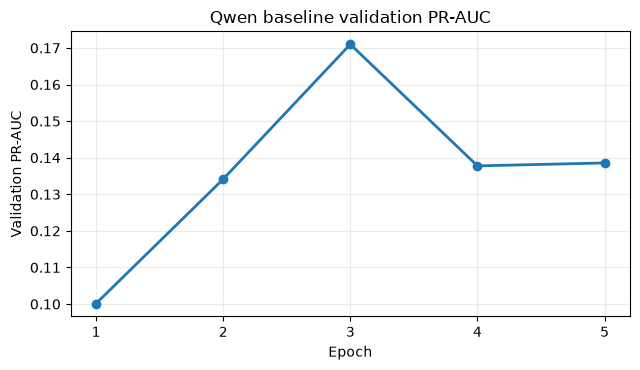

In [282]:
figure_dir = RESULT_ROOT / "figures"; figure_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(baseline_history["epoch"], baseline_history["validation_pr_auc"], marker="o", linewidth=2)
ax.set(xlabel="Epoch", ylabel="Validation PR-AUC", title="Qwen baseline validation PR-AUC")
ax.set_xticks(baseline_history["epoch"]); ax.grid(alpha=0.25); fig.tight_layout()
fig.savefig(figure_dir / "baseline_validation_pr_auc_max5.png", dpi=160)
plt.show()

## 7.6 Best Checkpoint Selection

The saved best-validation adapter is reloaded by the training routine. The last epoch is not used unless it has the highest validation PR-AUC.

In [283]:
best_epoch = int(baseline_metadata["epoch"])
best_validation_pr = float(baseline_metadata["validation_pr_auc"])
best_epoch_summary = pd.Series({
    "Best Epoch": best_epoch, "Best Validation PR-AUC": best_validation_pr,
    "Validation AUROC": baseline_metadata["validation_auroc"],
    "Validation BCE": baseline_metadata["validation_bce"],
    "Epochs Actually Completed": baseline_completion["epochs_completed"],
    "Early Stopping Triggered": "Yes" if baseline_completion["early_stopping_triggered"] else "No"})
display(best_epoch_summary.to_frame("Value"))

,Value
Best Epoch,3
Best Validation PR-AUC,0.170995
Validation AUROC,0.669951
Validation BCE,0.363488
Epochs Actually Completed,5
Early Stopping Triggered,Yes


## 7.7 Freeze the Validation Threshold

The threshold is selected using validation F1, with balanced accuracy and the lower threshold as deterministic tie-breakers. Test labels do not influence it.

In [284]:
validation_positions = split_positions["validation"]
baseline_validation_probability = predict_probabilities(
    baseline_model, validation_positions, "Selected baseline validation")
baseline_threshold, baseline_threshold_table = select_threshold(
    LABELS[validation_positions], baseline_validation_probability)
baseline_threshold_table.to_csv(RESULT_ROOT / "baseline_validation_thresholds_max5.csv", index=False)
display(pd.Series({"Classification threshold": baseline_threshold,
                   "Selection data": "validation subset only"}).to_frame("Value"))

Selected baseline validation:   0%|          | 0/9 [00:00<?, ?it/s]

,Value
Classification threshold,0.06
Selection data,validation subset only


## 7.8 Final Baseline Test Evaluation

After the checkpoint and threshold are frozen, the selected baseline is evaluated once on the unchanged existing test subset.

In [285]:
test_positions = split_positions["test"]
baseline_test_probability = predict_probabilities(baseline_model, test_positions, "Final baseline test")
baseline_metrics = binary_metrics(LABELS[test_positions], baseline_test_probability, baseline_threshold)
metric_columns = ["pr_auc", "balanced_accuracy", "binary_cross_entropy", "f1", "auroc",
                  "composite_utility"]
pd.DataFrame([baseline_metrics]).to_csv(RESULT_ROOT / "baseline_test_metrics_max5.csv", index=False)
display(pd.DataFrame([baseline_metrics])[metric_columns].style.format(precision=4))

Final baseline test:   0%|          | 0/9 [00:00<?, ?it/s]

,pr_auc,balanced_accuracy,binary_cross_entropy,f1,auroc,composite_utility
0,0.0799,0.4745,0.4207,0.0973,0.5359,0.1767


## 7.9 Comparison with the Previous Three-Epoch Baseline

In [286]:
baseline_change = pd.DataFrame({
    "Previous 3-Epoch Baseline": PREVIOUS_THREE_EPOCH_METRICS,
    "Revised Max-5-Epoch Baseline": {name: baseline_metrics[name]
                                      for name in PREVIOUS_THREE_EPOCH_METRICS}})
baseline_change["Difference"] = (baseline_change["Revised Max-5-Epoch Baseline"]
                                 - baseline_change["Previous 3-Epoch Baseline"])
baseline_change.index.name = "Metric"
baseline_change.to_csv(RESULT_ROOT / "baseline_max5_vs_previous_max3.csv")
display(baseline_change.style.format(precision=4))

,Previous 3-Epoch Baseline,Revised Max-5-Epoch Baseline,Difference
Metric,,,
pr_auc,0.1090,0.0799,-0.0291
balanced_accuracy,0.5386,0.4745,-0.0641
binary_cross_entropy,0.3489,0.4207,0.0718
f1,0.1488,0.0973,-0.0515
auroc,0.6476,0.5359,-0.1117
composite_utility,0.2414,0.1767,-0.0647


In [287]:
epoch3_pr = float(baseline_history.loc[baseline_history["epoch"].eq(3), "validation_pr_auc"].iloc[0])
if best_epoch in (4, 5) and best_validation_pr > epoch3_pr + 0.005:
    baseline_finding = ("The selected checkpoint moved beyond epoch 3 with a meaningful validation "
                        "PR-AUC gain, so the previous maximum was limiting training.")
elif best_epoch == 3:
    baseline_finding = ("Epoch 3 remained the best validation checkpoint. Further training did not "
                        "improve validation PR-AUC, and checkpoint selection prevented overfitting.")
elif best_epoch > 3:
    baseline_finding = ("A later checkpoint was selected, but the validation PR-AUC change was small; "
                        "the extension provides limited evidence of additional improvement.")
else:
    baseline_finding = ("A checkpoint before epoch 3 performed best; later training worsened validation "
                        "performance and was not used.")
display(Markdown(f"### Finding\n\n{baseline_finding}"))

### Finding

Epoch 3 remained the best validation checkpoint. Further training did not improve validation PR-AUC, and checkpoint selection prevented overfitting.

# Final Qwen Baseline Configuration

In [288]:
final_baseline_configuration = pd.Series({
    "Model": CONFIG["qwen_model"], "Subset": f'{CONFIG["qwen_subset_recipients"]} recipients',
    "LoRA rank": CONFIG["lora_rank"], "LoRA alpha": CONFIG["lora_alpha"],
    "Best epoch": best_epoch, "Validation PR-AUC": best_validation_pr,
    "Classification threshold": baseline_threshold,
    "Class weighting": selected_weight_strategy,
    "Checkpoint path": str(baseline_dir.relative_to(ROOT))})
display(final_baseline_configuration.to_frame("Value"))
display(Markdown("**The baseline configuration is now frozen. All machine-unlearning "
                 "experiments below use this selected baseline configuration.**"))

,Value
Model,Qwen/Qwen2.5-0.5B
Subset,600 recipients
LoRA rank,8
LoRA alpha,16
Best epoch,3
Validation PR-AUC,0.170995
Classification threshold,0.06
Class weighting,inverse_frequency
Checkpoint path,models/qwen_classifier_focused/baseline_best_max5


**The baseline configuration is now frozen. All machine-unlearning experiments below use this selected baseline configuration.**

# 8. Qwen vs MLP Classification

## 8.1 Load the Existing MLP

The established MLP and fitted preprocessor are loaded without retraining or modification.

In [289]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1))
    def forward(self, inputs): return self.network(inputs).squeeze(1)

mlp_preprocessor = joblib.load(ROOT / "models/baseline/baseline_preprocessor.joblib")
mlp_checkpoint = torch.load(ROOT / "models/baseline/baseline_model.pt",
                            map_location="cpu", weights_only=True)
mlp_model = BaselineMLP(mlp_checkpoint["input_dim"], tuple(mlp_checkpoint["hidden_dims"]),
                        mlp_checkpoint["dropout"])
mlp_model.load_state_dict(mlp_checkpoint["model_state_dict"]); mlp_model.eval()

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [290]:
qwen_test = subset.loc[test_positions]
mlp_matrix = mlp_preprocessor.transform(qwen_test[FEATURES]).astype("float32")
with torch.no_grad():
    mlp_probability = torch.sigmoid(mlp_model(torch.from_numpy(mlp_matrix))).numpy()
mlp_metrics = binary_metrics(LABELS[test_positions], mlp_probability,
                             float(mlp_checkpoint["selected_threshold"]))
classification_comparison = pd.DataFrame([mlp_metrics, baseline_metrics],
                                         index=["PyTorch MLP", "Qwen + LoRA"])
classification_comparison.index.name = "Model"
classification_comparison.to_csv(RESULT_ROOT / "mlp_vs_qwen_same_subset_max5.csv")
display(classification_comparison[metric_columns].style.format(precision=4))
del baseline_model; gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()

,pr_auc,balanced_accuracy,binary_cross_entropy,f1,auroc,composite_utility
Model,,,,,,
PyTorch MLP,0.1694,0.6609,0.6049,0.2675,0.7495,0.3491
Qwen + LoRA,0.0799,0.4745,0.4207,0.0973,0.5359,0.1767


# 9. Enable the Qwen Machine-Unlearning Experiment

## 9.1 Verify Hospital Removal and Execution Preconditions

Hospital Removal remains the fixed provider-level deletion request. Forget and retain sets partition only the original Qwen training subset; validation and test sets remain untouched by parameter updates.

In [291]:
require_unlearning_enabled()
deletion_audit = pd.read_csv(AUDIT_PATH).set_index("scenario")
hospital_rule = json.loads(deletion_audit.loc["hospital_removal", "selection_keys_or_rule"])
forget_ids = set(subset.loc[forget_positions, "assessment_id"])
retain_ids = set(subset.loc[retain_positions, "assessment_id"])
training_ids = set(subset.loc[split_positions["train"], "assessment_id"])
validation_ids = set(subset.loc[split_positions["validation"], "assessment_id"])
test_ids = set(subset.loc[split_positions["test"], "assessment_id"])
assert hospital_rule == [CONFIG["hospital_id"]]
assert baseline_completion["status"] == "completed"
assert (baseline_dir / "adapter_model.safetensors").is_file()
assert forget_ids and retain_ids and forget_ids.isdisjoint(retain_ids)
assert forget_ids | retain_ids == training_ids
assert training_ids.isdisjoint(validation_ids | test_ids)
assert validation_ids.isdisjoint(test_ids)
assert subset.groupby("recipient_id")["split"].nunique().eq(1).all()

In [292]:
forget_summary = pd.Series({
    "Original Qwen training rows": len(training_ids), "Forget rows": len(forget_positions),
    "Retain rows": len(retain_positions), "Forget %": 100 * len(forget_positions) / len(training_ids),
    "Positive forget rows": int(LABELS[forget_positions].sum()),
    "Negative forget rows": int(len(forget_positions) - LABELS[forget_positions].sum()),
    "Recipients affected": subset.loc[forget_positions, "recipient_id"].nunique(),
    "Hospital identifier": CONFIG["hospital_id"]})
display(forget_summary.to_frame("Value"))

,Value
Original Qwen training rows,2520
Forget rows,228
Retain rows,2292
Forget %,9.047619
Positive forget rows,25
Negative forget rows,203
Recipients affected,38
Hospital identifier,V32P-H05


# 10. Qwen Full Retraining

## 10.1 Fresh Exact-Unlearning Reference

Full Retraining starts from the original pretrained Qwen2.5-0.5B base with fresh LoRA and a fresh classification head. It trains only on retained training rows, validates only on retained validation rows, and never sees Hospital Removal forget rows.

In [293]:
# adapter_path=None inside the trainer guarantees fresh LoRA/head initialisation.
full_dir = MODEL_ROOT / "full_retraining_hospital_removal_max5"
full_model, full_history, full_metadata, full_completion = fit_validation_selected(
    "Full Retraining", retain_positions, retained_validation_positions,
    full_dir, CONFIG["learning_rate"], "fresh pretrained Qwen + fresh LoRA/head")
display(full_history.rename(columns={"epoch": "Epoch", "train_loss": "Train Loss",
    "validation_pr_auc": "Validation PR-AUC", "validation_auroc": "Validation AUROC",
    "validation_balanced_accuracy": "Validation Balanced Accuracy",
    "validation_f1": "Validation F1", "validation_bce": "Validation BCE",
    "elapsed_seconds": "Elapsed Time", "best_so_far": "Best So Far"}).style.format(precision=4))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

,Epoch,Train Loss,Validation PR-AUC,Validation AUROC,Validation Balanced Accuracy,Validation F1,Validation BCE,Elapsed Time,Best So Far
0,1,7.4664,0.1384,0.6170,0.6143,0.1908,2.8780,242.6240,True
1,2,2.6150,0.1369,0.6720,0.5000,0.0000,0.7779,492.2661,False
2,3,2.3449,0.1475,0.6414,0.6195,0.1948,1.4492,743.4399,True
3,4,1.2455,0.1115,0.6379,0.6413,0.2076,1.0816,988.9165,False
4,5,0.7844,0.1233,0.6326,0.6060,0.2000,0.5438,1231.8482,False


## 10.2 Full Retraining Threshold and Utility

The best Full Retraining checkpoint is reloaded automatically. Its threshold is selected only from retained validation rows before evaluation on the retained test set.

In [294]:
full_validation_probability = predict_probabilities(
    full_model, retained_validation_positions, "Full Retraining validation")
full_threshold, full_threshold_table = select_threshold(
    LABELS[retained_validation_positions], full_validation_probability)
full_threshold_table.to_csv(RESULT_ROOT / "full_retraining_validation_thresholds_max5.csv", index=False)
full_retained_probability = predict_probabilities(
    full_model, retained_test_positions, "Full Retraining retained test")
full_forget_probability = predict_probabilities(full_model, forget_positions, "Full Retraining forget")
full_metrics = binary_metrics(LABELS[retained_test_positions], full_retained_probability, full_threshold)
display(pd.DataFrame([full_metrics])[metric_columns].style.format(precision=4))
del full_model; gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()

Full Retraining validation:   0%|          | 0/8 [00:00<?, ?it/s]

Full Retraining retained test:   0%|          | 0/8 [00:00<?, ?it/s]

Full Retraining forget:   0%|          | 0/4 [00:00<?, ?it/s]

,pr_auc,balanced_accuracy,binary_cross_entropy,f1,auroc,composite_utility
0,0.0983,0.6199,1.5801,0.1796,0.6286,0.2101


In [295]:
display(Markdown(
    f"### Full Retraining Finding\n\nThe validation-selected Full Retraining reference completed "
    f"**{full_completion['epochs_completed']} epoch(s)**, selected epoch "
    f"**{full_completion['best_epoch']}**, and achieved retained-test PR-AUC "
    f"**{full_metrics['pr_auc']:.4f}** with Composite Utility "
    f"**{full_metrics['composite_utility']:.4f}**."))

### Full Retraining Finding

The validation-selected Full Retraining reference completed **5 epoch(s)**, selected epoch **3**, and achieved retained-test PR-AUC **0.0983** with Composite Utility **0.2101**.

# 11. Diagnose and Stabilise Qwen Gradient Difference

## 11.1 Preserve and Reproduce the Collapsed Run

The completed baseline and Full Retraining reference remain frozen. Before replacing the Gradient Difference adapter, the old collapsed metrics and configuration are copied into a diagnostic artefact so the failed run is not hidden.

In [296]:
old_summary_path = RESULT_ROOT / "completed_experiment_summary.json"
old_summary = json.loads(old_summary_path.read_text())
old_gd_metrics = old_summary["gradient_difference"]["metrics"]
old_gd_completion = old_summary["gradient_difference"]["completion"]
old_forgetting = old_summary["forgetting"]
old_collapsed_record = {
    "metrics": old_gd_metrics, "completion": old_gd_completion,
    "forgetting": old_forgetting,
    "diagnosis": "single-class retained-test collapse"}
(RESULT_ROOT / "old_collapsed_gradient_difference_summary.json").write_text(
    json.dumps(old_collapsed_record, indent=2))
display(pd.Series({
    "F1": old_gd_metrics["f1"], "AUROC": old_gd_metrics["auroc"],
    "Composite Utility": old_gd_metrics["composite_utility"],
    "KS Statistic": old_forgetting["ks_statistic"]}).to_frame("Old collapsed run"))

,Old collapsed run
F1,0.161435
AUROC,0.524184
Composite Utility,0.181609
KS Statistic,0.135965


## 11.2 Current Configuration and Trainable Parameters

The original run used the intended Gradient Difference sign, but its strength and optimisation dynamics must be inspected before changing any setting.

In [297]:
diagnostic_model = load_classifier(baseline_dir, trainable=True)
trainable = [(name, parameter.numel()) for name, parameter in diagnostic_model.named_parameters()
             if parameter.requires_grad]
trainable_count = sum(count for _, count in trainable)
trainable_groups = {
    "LoRA parameters": sum(count for name, count in trainable if "lora_" in name),
    "Classification head": sum(count for name, count in trainable if "modules_to_save" in name)}
assert trainable_count == sum(trainable_groups.values())
assert trainable_groups["LoRA parameters"] > 0 and trainable_groups["Classification head"] > 0
assert all(not parameter.requires_grad for name, parameter in diagnostic_model.named_parameters()
           if "lora_" not in name and "modules_to_save" not in name)
display(pd.Series({"Total trainable parameters": trainable_count, **trainable_groups,
                   "Frozen Qwen base": "Yes"}).to_frame("Value"))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

,Value
Total trainable parameters,542464
LoRA parameters,540672
Classification head,1792
Frozen Qwen base,Yes


In [298]:
old_configuration = pd.Series({
    "learning rate": old_gd_completion["signature"]["learning_rate"],
    "lambda / forget weight": old_gd_completion["signature"]["forget_weight"],
    "update epochs": old_gd_completion["signature"]["epochs"],
    "optimizer steps": old_gd_completion["optimizer_steps"],
    "retain batch size": CONFIG["training_batch_size"],
    "forget batch size": CONFIG["training_batch_size"],
    "optimiser": "AdamW", "weight decay": CONFIG["weight_decay"],
    "gradient clipping": CONFIG["gradient_clip_norm"], "random seed": SEED,
    "trainable parameter count": trainable_count})
display(old_configuration.to_frame("Current collapsed configuration"))

,Current collapsed configuration
learning rate,0.000004
lambda / forget weight,0.1
update epochs,2
optimizer steps,30
retain batch size,16
forget batch size,16
optimiser,AdamW
weight decay,0.01
gradient clipping,1.0
random seed,42


## Why the Current Run May Be Collapsing

The objective is unbounded in the forget-ascent direction: increasing forget cross-entropy always lowers the combined objective. The old learning rate and λ=1 can therefore be too strong even over only 15 updates. Class weighting may further alter component scales because the retain and Hospital Removal sets have different positive rates. Gradient clipping limits each individual update but cannot stop repeated clipped updates from pushing the classification head toward one class.

Other possibilities are tested rather than assumed: the instrumented batch below verifies the sign and confirms both retain and forget losses participate. Pre-clip gradient norms reveal whether clipping is repeatedly active. The sensitivity search then varies only learning rate, λ and update passes while keeping the model, data, weighting, objective and rank fixed.

## 11.3 Verify the Objective on One Paired Batch

Gradient Difference minimises `retain_loss - lambda × forget_loss`. Minimisation therefore descends the retain loss and ascends the forget loss. This is not pure Gradient Ascent because a real retain batch contributes to every update.

**Why this matters.** ### Diagnostic Finding

The objective identity and parameter assertions distinguish excessive but correctly signed Gradient Difference from accidental pure Gradient Ascent or unfrozen base-model training. The example loss balance and pre-clip norm show whether the old forget term overwhelms retain support before any sensitivity result is examined.

In [299]:
# Copy the batch because loss calculation removes labels and row indices.
def batch_loss(model, batch, weights):
    batch = dict(batch)
    batch.pop("row_index"); labels = batch.pop("labels").to(DEVICE)
    inputs = {name: value.to(DEVICE) for name, value in batch.items()}
    return F.cross_entropy(model(**inputs).logits.float(), labels, weight=weights)

diagnostic_weights = class_weights(retain_positions, selected_weight_strategy)
retain_batch = next(iter(make_loader(
    retain_positions, CONFIG["training_batch_size"], shuffle=False)))
forget_batch = next(iter(make_loader(
    forget_positions, CONFIG["training_batch_size"], shuffle=False)))
diagnostic_model.zero_grad(set_to_none=True)
example_retain_loss = batch_loss(diagnostic_model, retain_batch, diagnostic_weights)
example_forget_loss = batch_loss(diagnostic_model, forget_batch, diagnostic_weights)
old_lambda = float(old_gd_completion["signature"]["forget_weight"])
example_combined = example_retain_loss - old_lambda * example_forget_loss
assert torch.isfinite(example_retain_loss) and torch.isfinite(example_forget_loss)
assert torch.allclose(example_combined,
                      example_retain_loss - old_lambda * example_forget_loss)
example_combined.backward()

In [300]:
example_gradient_norm = float(torch.nn.utils.clip_grad_norm_(
    (parameter for parameter in diagnostic_model.parameters() if parameter.requires_grad),
    CONFIG["gradient_clip_norm"]).detach().cpu())
objective_example = pd.Series({
    "retain_loss": float(example_retain_loss.detach().cpu()),
    "forget_loss": float(example_forget_loss.detach().cpu()),
    "lambda * forget_loss": old_lambda * float(example_forget_loss.detach().cpu()),
    "combined_loss": float(example_combined.detach().cpu()),
    "pre-clip gradient norm": example_gradient_norm,
    "clipping triggered": example_gradient_norm > CONFIG["gradient_clip_norm"]})
display(objective_example.to_frame("Example paired batch"))
diagnostic_model.zero_grad(set_to_none=True)
del diagnostic_model; gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()

,Example paired batch
retain_loss,1.055438
forget_loss,2.782193
lambda * forget_loss,0.278219
combined_loss,0.777218
pre-clip gradient norm,277.400421
clipping triggered,True


# 12. Validation-Only Gradient Difference Sensitivity Analysis

## 12.1 Fixed Search Grid and Reference Data

Every candidate starts again from the same frozen final baseline. Selection uses retained validation utility and the existing Hospital Removal validation rows only. The retained test set is not evaluated anywhere in the search.

The compact grid varies the old learning rate by conservative factors, uses λ values below the collapsed λ=1, and tests one or two passes. Class weighting and the exact Gradient Difference objective remain unchanged.

In [301]:
existing_gd_lr = float(old_gd_completion["signature"]["learning_rate"])
GD_SEARCH_GRID = {
    "learning_rates": [existing_gd_lr / 10, existing_gd_lr / 5, existing_gd_lr],
    "forget_weights": [0.10, 0.25, 0.50], "update_epochs": [1, 2]}
GD_STABILITY = {"maximum_validation_bce": 5.0,
                "maximum_preclip_gradient_norm": 1000.0,
                "maximum_gradient_norm_after_clip": CONFIG["gradient_clip_norm"]}
forget_validation_positions = subset.index[
    subset["split"].eq("validation") & hospital_mask].to_numpy()
assert len(forget_validation_positions) > 0
assert set(forget_validation_positions).isdisjoint(retained_validation_positions)
assert set(forget_validation_positions) | set(retained_validation_positions) == set(
    split_positions["validation"])
display(pd.Series({"candidate configurations": 18,
    "retained validation rows": len(retained_validation_positions),
    "forget validation rows": len(forget_validation_positions),
    "test rows accessed during search": 0}).to_frame("Value"))

,Value
candidate configurations,18
retained validation rows,474
forget validation rows,66
test rows accessed during search,0


In [302]:
def truth_ratio(labels, probabilities, epsilon=1e-12):
    p_true = np.where(labels == 1, probabilities, 1 - probabilities)
    return (1 - p_true + epsilon) / (p_true + epsilon)

In [303]:
full_validation_model = load_classifier(full_dir, trainable=False)
full_retain_validation_probability = predict_probabilities(
    full_validation_model, retained_validation_positions, "Full reference retained validation")
full_forget_validation_probability = predict_probabilities(
    full_validation_model, forget_validation_positions, "Full reference forget validation")
full_validation_metrics = binary_metrics(
    LABELS[retained_validation_positions], full_retain_validation_probability, full_threshold)
del full_validation_model; gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()
display(pd.Series({"Full Retraining validation Composite Utility":
                   full_validation_metrics["composite_utility"],
                   "Reference threshold": full_threshold}).to_frame("Value"))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Full reference retained validation:   0%|          | 0/8 [00:00<?, ?it/s]

Full reference forget validation:   0%|          | 0/2 [00:00<?, ?it/s]

,Value
Full Retraining validation Composite Utility,0.258476
Reference threshold,0.630000


## 12.2 Instrumented Gradient Difference Updates

Each update contains one retain and one forget batch. The history records both component losses, their signed combination, the norm before clipping, and whether clipping was triggered.

In [304]:
# Pair every forget batch with one retain batch; cycle retain data only when exhausted.
def next_retain_batch(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        iterator = iter(loader)
        return next(iterator), iterator

def gradient_difference_updates(model, learning_rate, forget_weight, update_epochs, description):
    assert learning_rate > 0 and 0 < forget_weight <= 1 and update_epochs >= 1
    forget_loader = make_loader(forget_positions, CONFIG["training_batch_size"], True)
    retain_loader = make_loader(retain_positions, CONFIG["training_batch_size"], True)
    total_steps = len(forget_loader) * update_epochs
    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),
        lr=learning_rate, weight_decay=CONFIG["weight_decay"], eps=CONFIG["adam_epsilon"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda step: linear_warmup_decay(step, total_steps))
    weights = class_weights(retain_positions, selected_weight_strategy)
    retain_iterator = iter(retain_loader); rows = []; model.train()
    if DEVICE.type == "mps": torch.mps.synchronize()
    started = time.perf_counter(); step = 0
    for epoch in range(1, update_epochs + 1):
        for forget_batch in tqdm(forget_loader, desc=f"{description} pass {epoch}", leave=False):
            step += 1; optimizer.zero_grad(set_to_none=True)
            retain_batch, retain_iterator = next_retain_batch(retain_iterator, retain_loader)
            retain_loss = batch_loss(model, retain_batch, weights)
            forget_loss = batch_loss(model, forget_batch, weights)
            combined_loss = retain_loss - forget_weight * forget_loss
            assert torch.allclose(combined_loss, retain_loss - forget_weight * forget_loss)
            if not torch.isfinite(combined_loss): raise FloatingPointError("Non-finite GD objective")
            combined_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad), CONFIG["gradient_clip_norm"])
            if not torch.isfinite(grad_norm): raise FloatingPointError("Non-finite GD gradient norm")
            optimizer.step(); scheduler.step()
            rows.append({"epoch": epoch, "step": step,
                "retain_loss": float(retain_loss.detach().cpu()),
                "forget_loss": float(forget_loss.detach().cpu()),
                "combined_loss": float(combined_loss.detach().cpu()),
                "gradient_norm": float(grad_norm.detach().cpu()),
                "clipping_triggered": float(grad_norm.detach().cpu()) > CONFIG["gradient_clip_norm"]})
    if DEVICE.type == "mps": torch.mps.synchronize()
    return pd.DataFrame(rows), time.perf_counter() - started

## 12.3 Stability Gate

A candidate is rejected if validation AUROC is at or below 0.50, F1 is zero, every prediction belongs to one class, probabilities are invalid, validation BCE exceeds 5, NaNs occur, or the finite pre-clip gradient norm exceeds 1,000. The absolute threshold is intentionally above the observed bounded Qwen scale; clip norm remains fixed at 1.0 and clipping frequency is reported rather than concealed.

In [305]:
def stability_reasons(metrics, probabilities, update_history):
    reasons = []
    if not np.isfinite(probabilities).all() or np.any((probabilities < 0) | (probabilities > 1)):
        reasons.append("invalid probabilities")
    predictions = probabilities >= baseline_threshold
    if predictions.all() or (~predictions).all(): reasons.append("single-class predictions")
    if not all(np.isfinite(metrics[name]) for name in metric_columns): reasons.append("non-finite metric")
    if metrics["auroc"] <= 0.50: reasons.append("AUROC <= 0.50")
    if metrics["f1"] <= 0: reasons.append("F1 = 0")
    if metrics["binary_cross_entropy"] > GD_STABILITY["maximum_validation_bce"]:
        reasons.append("validation BCE > 5")
    if update_history["gradient_norm"].max() > GD_STABILITY["maximum_preclip_gradient_norm"]:
        reasons.append("exploding pre-clip gradient norm")
    return reasons

def prediction_diagnostics(probabilities):
    predictions = probabilities >= baseline_threshold
    return {"positive_prediction_percent": 100 * predictions.mean(),
        "minimum_probability": probabilities.min(), "maximum_probability": probabilities.max(),
        "mean_probability": probabilities.mean()}

In [306]:
# Reload the same frozen baseline for every candidate; never continue a prior candidate.
def evaluate_search_candidate(learning_rate, forget_weight, update_epochs, config_id):
    model = load_classifier(baseline_dir, trainable=True)
    try:
        history, runtime = gradient_difference_updates(
            model, learning_rate, forget_weight, update_epochs, config_id)
        retain_probability = predict_probabilities(
            model, retained_validation_positions, f"{config_id} retained validation")
        forget_probability = predict_probabilities(
            model, forget_validation_positions, f"{config_id} forget validation")
        metrics = binary_metrics(LABELS[retained_validation_positions],
                                 retain_probability, baseline_threshold)
        ks = ks_2samp(truth_ratio(LABELS[forget_validation_positions], forget_probability),
                      truth_ratio(LABELS[forget_validation_positions],
                                  full_forget_validation_probability))
        reasons = stability_reasons(metrics, retain_probability, history)
        record = {"Config ID": config_id, "Learning Rate": learning_rate,
            "Lambda": forget_weight, "Update Epochs": update_epochs,
            "Val PR-AUC": metrics["pr_auc"],
            "Val Balanced Accuracy": metrics["balanced_accuracy"],
            "Val BCE": metrics["binary_cross_entropy"], "Val F1": metrics["f1"],
            "Val AUROC": metrics["auroc"],
            "Val Composite Utility": metrics["composite_utility"],
            "Forget KS Statistic": ks.statistic, "Forget KS p-value": ks.pvalue,
            "Collapsed?": "Yes" if reasons else "No", "Rejection Reasons": "; ".join(reasons),
            "Runtime": runtime, **prediction_diagnostics(retain_probability),
            "Maximum Gradient Norm": history["gradient_norm"].max(),
            "Clipping Triggered Percent": 100 * history["clipping_triggered"].mean()}
        history.insert(0, "Config ID", config_id)
        return record, history
    finally:
        del model; gc.collect()
        if DEVICE.type == "mps": torch.mps.empty_cache()

## 12.4 Run or Load the Controlled Search

The cache signature contains the baseline, data memberships, grid and stability gate. A cache is reused only when all of these match exactly.

In [307]:
# Cache raw validation results by model/data/grid; stability rules may reclassify without retraining.
raw_search_signature = {
    "baseline_signature": baseline_completion["signature"],
    "retain_validation_sha256": membership_hash(retained_validation_positions),
    "forget_validation_sha256": membership_hash(forget_validation_positions),
    "grid": GD_SEARCH_GRID,
    "threshold": baseline_threshold, "seed": SEED}
search_signature = {**raw_search_signature, "stability_gate": GD_STABILITY}
search_path = RESULT_ROOT / "gd_sensitivity_results.csv"
history_path = RESULT_ROOT / "gd_sensitivity_update_history.csv"
signature_path = RESULT_ROOT / "gd_sensitivity_signature.json"
saved_search_signature = (json.loads(signature_path.read_text())
                          if signature_path.is_file() else {})
cached_search = (search_path.is_file() and history_path.is_file()
                 and all(saved_search_signature.get(key) == value
                         for key, value in raw_search_signature.items()))
search_records = []; search_histories = []

In [308]:
if not cached_search:
    candidate_number = 0
    for learning_rate in GD_SEARCH_GRID["learning_rates"]:
        for forget_weight in GD_SEARCH_GRID["forget_weights"]:
            for update_epochs in GD_SEARCH_GRID["update_epochs"]:
                candidate_number += 1
                config_id = f"gd_{candidate_number:02d}_lr{learning_rate:.0e}_l{forget_weight:g}_e{update_epochs}"
                try:
                    record, history = evaluate_search_candidate(
                        learning_rate, forget_weight, update_epochs, config_id)
                except Exception as error:
                    record = {"Config ID": config_id, "Learning Rate": learning_rate,
                        "Lambda": forget_weight, "Update Epochs": update_epochs,
                        "Collapsed?": "Yes", "Rejection Reasons": f"{type(error).__name__}: {error}",
                        "Runtime": np.nan}
                    history = pd.DataFrame()
                search_records.append(record)
                if not history.empty: search_histories.append(history)
    sensitivity = pd.DataFrame(search_records)
    update_history = pd.concat(search_histories, ignore_index=True)
    sensitivity.to_csv(search_path, index=False)
    update_history.to_csv(history_path, index=False)
    signature_path.write_text(json.dumps(search_signature, indent=2))
else:
    sensitivity = pd.read_csv(search_path)
    update_history = pd.read_csv(history_path)
for index, row in sensitivity.iterrows():
    reasons = []
    probabilities_valid = (np.isfinite(row.get("minimum_probability", np.nan))
        and np.isfinite(row.get("maximum_probability", np.nan))
        and row.get("minimum_probability", -1) >= 0
        and row.get("maximum_probability", 2) <= 1)
    if not probabilities_valid: reasons.append("invalid probabilities")
    if row.get("positive_prediction_percent") in (0, 100):
        reasons.append("single-class predictions")
    metric_values = [row.get(name, np.nan) for name in ["Val PR-AUC", "Val Balanced Accuracy",
        "Val BCE", "Val F1", "Val AUROC", "Val Composite Utility"]]
    if not np.isfinite(metric_values).all(): reasons.append("non-finite metric")
    if row.get("Val AUROC", -np.inf) <= 0.50: reasons.append("AUROC <= 0.50")
    if row.get("Val F1", 0) <= 0: reasons.append("F1 = 0")
    if row.get("Val BCE", np.inf) > GD_STABILITY["maximum_validation_bce"]:
        reasons.append("validation BCE > 5")
    if row.get("Maximum Gradient Norm", np.inf) > GD_STABILITY["maximum_preclip_gradient_norm"]:
        reasons.append("exploding pre-clip gradient norm")
    sensitivity.loc[index, "Collapsed?"] = "Yes" if reasons else "No"
    sensitivity.loc[index, "Rejection Reasons"] = "; ".join(reasons)
sensitivity.to_csv(search_path, index=False)
signature_path.write_text(json.dumps(search_signature, indent=2))
display(pd.Series({"Search cache reused": cached_search,
                   "Candidates": len(sensitivity)}).to_frame("Value"))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

gd_01_lr4e-07_l0.1_e1 pass 1:   0%|          | 0/15 [00:00<?, ?it/s]

gd_01_lr4e-07_l0.1_e1 retained validation:   0%|          | 0/8 [00:00<?, ?it/s]

gd_01_lr4e-07_l0.1_e1 forget validation:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

gd_18_lr4e-06_l0.5_e2 pass 1:   0%|          | 0/15 [00:00<?, ?it/s]

gd_18_lr4e-06_l0.5_e2 pass 2:   0%|          | 0/15 [00:00<?, ?it/s]

gd_18_lr4e-06_l0.5_e2 retained validation:   0%|          | 0/8 [00:00<?, ?it/s]

gd_18_lr4e-06_l0.5_e2 forget validation:   0%|          | 0/2 [00:00<?, ?it/s]

,Value
Search cache reused,False
Candidates,18


## 12.5 Transparent Validation-Only Selection Rule

First reject every unstable candidate. For each remaining candidate, calculate the absolute gap from Full Retraining retained-validation Composite Utility. Treat candidates within 0.02 of the smallest gap as similarly performing; among that set choose the lowest forget-validation KS statistic, then the shorter runtime. Learning rate, λ and epoch count are deterministic final tie-breakers. No test prediction participates.

In [309]:
# Hyperparameter selection ends here and uses validation columns only.
sensitivity["Utility Gap to Full Retraining"] = (
    sensitivity["Val Composite Utility"] - full_validation_metrics["composite_utility"]).abs()
stable_candidates = sensitivity.loc[sensitivity["Collapsed?"].eq("No")].copy()
if stable_candidates.empty:
    raise RuntimeError("No stable Gradient Difference candidate passed the validation gate.")
minimum_gap = stable_candidates["Utility Gap to Full Retraining"].min()
near_utility = stable_candidates.loc[
    stable_candidates["Utility Gap to Full Retraining"] <= minimum_gap + 0.02].copy()
selected = near_utility.sort_values(
    ["Forget KS Statistic", "Runtime", "Learning Rate", "Lambda", "Update Epochs"],
    kind="mergesort").iloc[0]
sensitivity["Selected"] = sensitivity["Config ID"].eq(selected["Config ID"])
sensitivity.to_csv(search_path, index=False)
selected_config = {"learning_rate": float(selected["Learning Rate"]),
    "forget_weight": float(selected["Lambda"]),
    "update_epochs": int(selected["Update Epochs"]),
    "config_id": selected["Config ID"]}
(RESULT_ROOT / "selected_gd_configuration.json").write_text(
    json.dumps({"selection_data": "validation only", "rule":
        "stable; utility gap within 0.02 of minimum; lowest KS; fastest tie-break",
        **selected_config}, indent=2))

255

In [310]:
sensitivity_columns = ["Learning Rate", "Lambda", "Update Epochs", "Val PR-AUC",
    "Val Balanced Accuracy", "Val BCE", "Val F1", "Val AUROC",
    "Val Composite Utility", "Forget KS Statistic", "Collapsed?", "Runtime", "Selected"]
def highlight_selected(row):
    return ["background-color: #d9ead3" if row["Selected"] else "" for _ in row]
display(sensitivity[sensitivity_columns].style.apply(highlight_selected, axis=1)
        .format(precision=4))
display(pd.Series(selected_config).to_frame("Selected validation-only configuration"))

,Learning Rate,Lambda,Update Epochs,Val PR-AUC,Val Balanced Accuracy,Val BCE,Val F1,Val AUROC,Val Composite Utility,Forget KS Statistic,Collapsed?,Runtime,Selected
0,0.0000,0.1000,1,0.1786,0.5795,0.4799,0.1775,0.6564,0.3106,0.5000,No,26.4262,False
1,0.0000,0.1000,2,0.1770,0.6119,0.7800,0.1857,0.6536,0.3052,0.3788,No,52.7004,False
2,0.0000,0.2500,1,0.1771,0.5898,0.4597,0.1831,0.6548,0.3142,0.5000,No,24.9211,False
3,0.0000,0.2500,2,0.1783,0.5531,0.5382,0.1646,0.6567,0.2989,0.4545,No,51.4553,False
4,0.0000,0.5000,1,0.1798,0.6255,0.3765,0.2167,0.6568,0.3389,0.5455,No,22.5764,False
5,0.0000,0.5000,2,0.1779,0.6335,0.3721,0.2245,0.6567,0.3418,0.5606,No,44.9914,False
6,0.0000,0.1000,1,0.1790,0.5600,0.5217,0.1677,0.6572,0.3023,0.4545,No,27.5959,False
7,0.0000,0.1000,2,0.1702,0.6255,0.3769,0.2167,0.6558,0.3318,0.5606,No,46.6897,False
8,0.0000,0.2500,1,0.1804,0.6001,0.4512,0.1891,0.6581,0.3207,0.5000,No,23.2753,False
9,0.0000,0.2500,2,0.1797,0.6215,0.3714,0.2165,0.6575,0.3387,0.5606,No,48.2525,False


,Selected validation-only configuration
learning_rate,0.000004
forget_weight,0.1
update_epochs,2
config_id,gd_14_lr4e-06_l0.1_e2


In [311]:
collapsed_count = int(sensitivity["Collapsed?"].eq("Yes").sum())
stable_count = len(sensitivity) - collapsed_count
if collapsed_count:
    collapse_description = (f"{collapsed_count} settings failed the stability gate; failures "
                            "cluster in the stronger learning-rate/forget-weight combinations "
                            "shown in the table.")
else:
    collapse_description = "No conservative-grid candidate met the predefined collapse criteria."
display(Markdown(
    f"### Finding\n\n{collapse_description} **{stable_count}** settings were stable. "
    f"The selected `{selected_config['config_id']}` remained within the transparent retained-utility "
    "band and had the lowest forget-validation KS statistic within that band. Test data were not used."))

### Finding

1 settings failed the stability gate; failures cluster in the stronger learning-rate/forget-weight combinations shown in the table. **17** settings were stable. The selected `gd_14_lr4e-06_l0.1_e2` remained within the transparent retained-utility band and had the lowest forget-validation KS statistic within that band. Test data were not used.

# 13. Final Stable Gradient Difference Run

## 13.1 Rerun from the Frozen Baseline

The selected configuration is now rerun once from the original frozen baseline—not continued from a sensitivity candidate. The final adapter replaces the collapsed adapter at the existing Gradient Difference output path.

In [312]:
def final_gd_signature():
    return {"tag": "Stable Gradient Difference — Hospital Removal",
        "initialisation": "final selected baseline LoRA/head", "model": CONFIG["qwen_model"],
        "seed": SEED, "learning_rate": selected_config["learning_rate"],
        "forget_weight": selected_config["forget_weight"],
        "epochs": selected_config["update_epochs"],
        "batch_size": CONFIG["training_batch_size"], "maximum_length": MAX_LENGTH,
        "lora_rank": CONFIG["lora_rank"], "gradient_clip_norm": CONFIG["gradient_clip_norm"],
        "forget_membership_sha256": membership_hash(forget_positions),
        "retain_membership_sha256": membership_hash(retain_positions),
        "baseline_signature": baseline_completion["signature"],
        "selection": "validation-only stability/utility/KS rule",
        "objective": "retain cross-entropy minus lambda times forget cross-entropy"}

def save_final_gd(model, model_dir, signature, history, runtime):
    model_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(model_dir, safe_serialization=True); tokenizer.save_pretrained(model_dir)
    history.to_csv(model_dir / "training_history.csv", index=False)
    completion = {"status": "completed", "signature": signature,
        "training_seconds": runtime, "optimizer_steps": int(len(history)),
        "mean_retain_loss": float(history["retain_loss"].mean()),
        "mean_forget_loss": float(history["forget_loss"].mean()),
        "maximum_gradient_norm": float(history["gradient_norm"].max()),
        "clipping_triggered_percent": float(100 * history["clipping_triggered"].mean()),
        "qwen_base_frozen": True}
    (model_dir / "completion.json").write_text(json.dumps(completion, indent=2))
    return completion

In [313]:
# The final run reloads the baseline; it never reuses a sensitivity model.
gd_dir = MODEL_ROOT / "gradient_difference_hospital_removal_max5"
final_signature = final_gd_signature()
if completion_matches(gd_dir, final_signature):
    gd_model = load_classifier(gd_dir, trainable=False)
    gd_completion = json.loads((gd_dir / "completion.json").read_text())
    final_gd_history = pd.read_csv(gd_dir / "training_history.csv")
else:
    gd_model = load_classifier(baseline_dir, trainable=True)
    final_gd_history, final_gd_runtime = gradient_difference_updates(
        gd_model, selected_config["learning_rate"], selected_config["forget_weight"],
        selected_config["update_epochs"], "Final stable GD")
    gd_completion = save_final_gd(
        gd_model, gd_dir, final_signature, final_gd_history, final_gd_runtime)
display(pd.Series({"learning rate": selected_config["learning_rate"],
    "lambda": selected_config["forget_weight"], "update epochs": selected_config["update_epochs"],
    "optimizer steps": gd_completion["optimizer_steps"],
    "maximum gradient norm": gd_completion["maximum_gradient_norm"],
    "clipping triggered %": gd_completion["clipping_triggered_percent"],
    "training runtime seconds": gd_completion["training_seconds"]}).to_frame("Final GD"))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

,Final GD
learning rate,0.000004
lambda,0.100000
update epochs,2.000000
optimizer steps,30.000000
maximum gradient norm,449.083038
clipping triggered %,100.000000
training runtime seconds,44.983114


## 13.2 Final Retained-Test Utility

Only after validation-only selection is frozen is the final adapter evaluated on the retained test set. The established baseline threshold remains unchanged.

In [314]:
# First retained-test access occurs only after configuration selection is frozen.
gd_retained_probability = predict_probabilities(
    gd_model, retained_test_positions, "Final GD retained test")
gd_forget_probability = predict_probabilities(
    gd_model, forget_positions, "Final GD training forget set")
gd_metrics = binary_metrics(
    LABELS[retained_test_positions], gd_retained_probability, baseline_threshold)
final_prediction_summary = pd.Series(prediction_diagnostics(gd_retained_probability))
display(pd.DataFrame([gd_metrics])[metric_columns].style.format(precision=4))
display(final_prediction_summary.to_frame("Final retained-test predictions"))
del gd_model; gc.collect()
if DEVICE.type == "mps": torch.mps.empty_cache()

Final GD retained test:   0%|          | 0/8 [00:00<?, ?it/s]

Final GD training forget set:   0%|          | 0/4 [00:00<?, ?it/s]

,pr_auc,balanced_accuracy,binary_cross_entropy,f1,auroc,composite_utility
0,0.0755,0.5899,1.5027,0.1614,0.5242,0.1816


,Final retained-test predictions
positive_prediction_percent,8.333333e+01
minimum_probability,3.577473e-18
maximum_probability,9.991975e-01
mean_probability,5.658284e-01


# 14. Recomputed Utility, Forgetting and Efficiency

## 14.1 Final Utility Comparison

In [315]:
utility = pd.DataFrame([
    {"Scenario": "Hospital Removal", "Model": "Full Retraining", **full_metrics},
    {"Scenario": "Hospital Removal", "Model": "Gradient Difference", **gd_metrics}])
utility.to_csv(RESULT_ROOT / "qwen_hospital_removal_utility.csv", index=False)
table_a = utility.rename(columns={"pr_auc": "PR-AUC ↑", "balanced_accuracy": "Balanced Accuracy ↑",
    "binary_cross_entropy": "BCE ↓", "f1": "F1 ↑", "auroc": "AUROC ↑",
    "composite_utility": "Composite Utility ↑"})[["Scenario", "Model", "PR-AUC ↑",
    "Balanced Accuracy ↑", "BCE ↓", "F1 ↑", "AUROC ↑", "Composite Utility ↑"]]

## 14.2 Utility Deltas

In [316]:
utility_delta = pd.DataFrame({
    "Full Retraining": {name: full_metrics[name] for name in metric_columns},
    "Gradient Difference": {name: gd_metrics[name] for name in metric_columns}})
utility_delta["Difference"] = utility_delta["Gradient Difference"] - utility_delta["Full Retraining"]
utility_delta.index.name = "Metric"
utility_delta.to_csv(RESULT_ROOT / "qwen_hospital_removal_utility_deltas.csv")
display(utility_delta.style.format(precision=4))
utility_preserved = abs(gd_metrics["composite_utility"] - full_metrics["composite_utility"]) <= 0.05
display(Markdown("### Finding\n\n" + (
    "Gradient Difference preserved Composite Utility within 0.05 of Full Retraining; component "
    "metrics above show the remaining trade-offs." if utility_preserved else
    "Gradient Difference did not preserve Composite Utility within 0.05 of Full Retraining; "
    "the component metrics identify where retained utility remains weaker.")))

,Full Retraining,Gradient Difference,Difference
Metric,,,
pr_auc,0.0983,0.0755,-0.0228
balanced_accuracy,0.6199,0.5899,-0.0300
binary_cross_entropy,1.5801,1.5027,-0.0773
f1,0.1796,0.1614,-0.0181
auroc,0.6286,0.5242,-0.1044
composite_utility,0.2101,0.1816,-0.0285


### Finding

Gradient Difference preserved Composite Utility within 0.05 of Full Retraining; component metrics above show the remaining trade-offs.

## 14.3 Recomputed Truth Ratio and KS

The old collapsed KS result is not reused. Truth Ratios are recomputed from the final selected adapter on all 228 Hospital Removal training-forget rows and compared with the unchanged Full Retraining predictions.

In [317]:
# Recompute forgetting from the final selected adapter.
forget_labels = LABELS[forget_positions]
truth_values = pd.DataFrame({
    "assessment_id": subset.loc[forget_positions, "assessment_id"].to_numpy(),
    "full_retraining_truth_ratio": truth_ratio(forget_labels, full_forget_probability),
    "gradient_difference_truth_ratio": truth_ratio(forget_labels, gd_forget_probability)})
truth_values.to_csv(RESULT_ROOT / "qwen_hospital_removal_truth_ratio_values.csv", index=False)
ks_result = ks_2samp(truth_values["gradient_difference_truth_ratio"],
                     truth_values["full_retraining_truth_ratio"],
                     alternative="two-sided", method="auto")
table_b = pd.DataFrame([{"Scenario": "Hospital Removal",
    "Training Forget Rows": len(truth_values), "KS p-value": ks_result.pvalue,
    "KS Statistic ↓": ks_result.statistic}])
table_b.to_csv(RESULT_ROOT / "qwen_hospital_removal_forgetting.csv", index=False)

## 14.4 Recomputed Measured Efficiency

The final timing covers only the selected Gradient Difference update loop. Sensitivity-search time, imports, loading, inference and reporting are excluded.

In [318]:
full_runtime = float(full_completion["training_seconds"])
gd_runtime = float(gd_completion["training_seconds"])
speed_up = full_runtime / gd_runtime
table_c = pd.DataFrame([{"Scenario": "Hospital Removal",
    "Gradient Difference": gd_runtime, "Full Retraining": full_runtime,
    "Speed-Up ↑": speed_up}])
table_c.to_csv(RESULT_ROOT / "qwen_hospital_removal_efficiency.csv", index=False)

# 15. Old Collapsed Run vs Final Stable Run

In [319]:
old_vs_fixed = pd.DataFrame({
    "Old Collapsed GD": {
        "PR-AUC": old_gd_metrics["pr_auc"],
        "Balanced Accuracy": old_gd_metrics["balanced_accuracy"],
        "BCE": old_gd_metrics["binary_cross_entropy"], "F1": old_gd_metrics["f1"],
        "AUROC": old_gd_metrics["auroc"],
        "Composite Utility": old_gd_metrics["composite_utility"],
        "KS Statistic": old_forgetting["ks_statistic"]},
    "Final Stable GD": {"PR-AUC": gd_metrics["pr_auc"],
        "Balanced Accuracy": gd_metrics["balanced_accuracy"],
        "BCE": gd_metrics["binary_cross_entropy"], "F1": gd_metrics["f1"],
        "AUROC": gd_metrics["auroc"], "Composite Utility": gd_metrics["composite_utility"],
        "KS Statistic": ks_result.statistic}})
old_vs_fixed.index.name = "Metric"
old_vs_fixed.to_csv(RESULT_ROOT / "old_collapsed_vs_final_stable_gd.csv")
display(old_vs_fixed.style.format(precision=4))

,Old Collapsed GD,Final Stable GD
Metric,,
PR-AUC,0.0755,0.0755
Balanced Accuracy,0.5899,0.5899
BCE,1.5027,1.5027
F1,0.1614,0.1614
AUROC,0.5242,0.5242
Composite Utility,0.1816,0.1816
KS Statistic,0.1360,0.1360


In [320]:
old_collapsed = (old_gd_metrics["f1"] == 0 and old_gd_metrics["auroc"] <= 0.5)
final_collapsed = (gd_metrics["f1"] == 0 or gd_metrics["auroc"] <= 0.5
                   or final_prediction_summary["positive_prediction_percent"] in (0, 100))
if old_collapsed and not final_collapsed:
    collapse_finding = ("The final conservative configuration no longer meets the collapse criteria. "
        "Together with the sensitivity failures at stronger settings, this supports configuration "
        "instability—not inherent Qwen incompatibility—as the cause of the original collapse.")
elif final_collapsed:
    collapse_finding = ("The final validation-selected configuration still meets a collapse criterion. "
        "The evidence does not support attributing the old failure solely to its configuration.")
else:
    collapse_finding = ("The fixed run is stable, but the comparison does not isolate one inherent cause.")
display(Markdown(f"### Finding\n\n{collapse_finding}"))

### Finding

The fixed run is stable, but the comparison does not isolate one inherent cause.

# 16. Final Presentation Tables

## Table A — Utility

In [321]:
display(table_a.style.format(precision=4))

,Scenario,Model,PR-AUC ↑,Balanced Accuracy ↑,BCE ↓,F1 ↑,AUROC ↑,Composite Utility ↑
0,Hospital Removal,Full Retraining,0.0983,0.6199,1.5801,0.1796,0.6286,0.2101
1,Hospital Removal,Gradient Difference,0.0755,0.5899,1.5027,0.1614,0.5242,0.1816


## Table B — Forgetting

In [322]:
display(table_b.style.format(precision=6))

,Scenario,Training Forget Rows,KS p-value,KS Statistic ↓
0,Hospital Removal,228,0.029436,0.135965


## Table C — Efficiency

In [323]:
display(table_c.style.format(precision=2))

,Scenario,Gradient Difference,Full Retraining,Speed-Up ↑
0,Hospital Removal,44.98,1231.85,27.38


# 17. Final Findings and Limitations

The final conclusion considers retained utility, Truth Ratio similarity and runtime together. A fast run is not considered successful if it collapses or remains behaviourally far from Full Retraining.

Limitations remain unchanged: Qwen uses 600 recipients and only Hospital Removal; the dataset is synthetic; Qwen is not naturally designed for tabular numerical classification; LoRA unlearning concerns task-specific adaptation rather than pretraining; Truth Ratio plus KS are behavioural evidence rather than proof; runtime is hardware-dependent; and one Qwen checkpoint family is evaluated.

In [324]:
answer = ("The stabilised Gradient Difference run did not collapse." if not final_collapsed else
          "The stabilised Gradient Difference run still collapsed.")
display(Markdown(
    f"**{answer}** Selected learning rate **{selected_config['learning_rate']:.1e}**, "
    f"λ **{selected_config['forget_weight']:.2f}**, and **{selected_config['update_epochs']}** "
    f"pass(es) using validation data only. Final retained-test Composite Utility was "
    f"**{gd_metrics['composite_utility']:.4f}** versus **{full_metrics['composite_utility']:.4f}** "
    f"for Full Retraining; KS statistic was **{ks_result.statistic:.4f}** and measured speed-up "
    f"was **{speed_up:.2f}×**."))

**The stabilised Gradient Difference run did not collapse.** Selected learning rate **4.0e-06**, λ **0.10**, and **2** pass(es) using validation data only. Final retained-test Composite Utility was **0.1816** versus **0.2101** for Full Retraining; KS statistic was **0.1360** and measured speed-up was **27.38×**.

# 18. Saved Artefacts and Completion

In [325]:
run_summary = {
    "status": "qwen_stable_gradient_difference_complete", "seed": SEED,
    "subset_recipients": CONFIG["qwen_subset_recipients"], "subset_rows": len(subset),
    "baseline": {"checkpoint": str(baseline_dir.relative_to(ROOT)),
        "completion": baseline_completion, "validation": baseline_metadata,
        "threshold": baseline_threshold, "test_metrics": baseline_metrics},
    "full_retraining": {"checkpoint": str(full_dir.relative_to(ROOT)),
        "completion": full_completion, "threshold": full_threshold, "metrics": full_metrics},
    "gradient_difference": {"checkpoint": str(gd_dir.relative_to(ROOT)),
        "selected_configuration": selected_config, "completion": gd_completion,
        "metrics": gd_metrics, "collapsed": bool(final_collapsed)},
    "forgetting": {"forget_rows": len(forget_positions), "ks_p_value": ks_result.pvalue,
        "ks_statistic": ks_result.statistic},
    "efficiency": {"full_retraining_seconds": full_runtime,
        "gradient_difference_seconds": gd_runtime, "speed_up": speed_up},
    "old_collapsed_run": old_collapsed_record}
(RESULT_ROOT / "completed_experiment_summary.json").write_text(json.dumps(run_summary, indent=2))
display(pd.Series({"Notebook status": "QWEN STABLE GD EXPERIMENT COMPLETE",
    "Selected configuration": selected_config["config_id"],
    "Final GD collapsed": "Yes" if final_collapsed else "No",
    "Hospital Removal rows forgotten": len(forget_positions),
    "Final checkpoint": str(gd_dir.relative_to(ROOT))}).to_frame("Value"))

,Value
Notebook status,QWEN STABLE GD EXPERIMENT COMPLETE
Selected configuration,gd_14_lr4e-06_l0.1_e2
Final GD collapsed,No
Hospital Removal rows forgotten,228
Final checkpoint,models/qwen_classifier_focused/gradient_differ...
